# Getting LIGO data

This notebook demonstrates how to obtain a long segment of noise-only LIGO data, that we can split up into shorter segements for training a noise model.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [4]:
import numpy as np
import pandas as pd
import h5py
from matplotlib import pyplot as plt

## Gravitational-wave data primer

Gravitational-wave (GW) data consist of time series natively sampled at 16 kHz (but usually downsampled to 4kHz or 2kHz before analysis). The measurement process is linear, with additive noise: for a set of parameters $\theta$ the corresponding signal $h(t;\theta)$ is fully deterministic and appears in the detector data $d$ like
$$
d(t) = h(t; \theta) + n(t)
$$
where $n(t)$ is instrumental noise, always assumed to be statinoary and Gaussian (with a known, colored power spectrum) during parameter estimation---assumptions we want to relax.

There are currently 3 operational GW detectors, so there may be up to 3 relevant data streams at any given time.
The noise at the detectors is (to great approximation---although not exacly) independent, so these enter the likelihood simply like 
$$
p(\{d_i\} \mid \theta) = \prod p(d_i \mid \theta)
$$
where $d_i$ are the data for the $i$th detector. The statistics are different for each detector, even if we assume Gaussian noise in all of them as we always do (in other words, the detectors have different covariance matrices). As always, $p(d_i \mid \theta)$ is obtained from the residuals $d_i(t) - h_i(t;\theta)$, which should be distributed like $n(t)$.

In reality, the noise $n(t)$ is only aproximated by a statinoary Gaussian process, because:
1. the data are contaminated by non-Gaussian instrumental transients (aka, "glitches"),
2. in theory, there are very weak GW signals hiding in the noise at any given time,
3. the overall state of the instrument evolves with time

A GW signal lasts anywhere from $\sim 1/5 s$ to minutes, and so do glitches; the baseline state of the instrument varies on scales of hours. The shortest segments we use during parameter estimation are $4s$ long, but we can go up to $128s$ for longer signals.

If glitches are very loud or if something else goes wrong, there might be missing data for certain times; but those times are (necessarily) unavailable for parameter estimation, so we don't need to worry much about those drops here.

## Downloading the data

GW data are made publicly available through the Gravitational-Wave Open Science Center ([GWOSC](https://gw-openscience.org)), both in bulk and for shorter period surrounding confirmed detections.

There are many ways to access these data programatically---e.g., using the [GWpy package](https://gwpy.github.io/docs/stable/timeseries/io/#automatic-discovery-of-gw-detector-data). However, if we know a priori what data we want, the one requiring the least overhead is to just download HDF5 files from GWOSC, as we do below.

### GW150914

As an example, we will download data around the first detection ([GW150914](https://en.wikipedia.org/wiki/First_observation_of_gravitational_waves)). We will download $1h$ and chop it up into $4s$ segments, avoiding the time containing the actual signal; we will download $4kHz$ data to make things faster---but we should think about whether we want to go all the way up to $16kHz$ (which is also available).

For the first detection, only the two LIGO detectors, Hanford (H1) and Livingston (L1), were available (the European detector, Virgo, wasn't operating yet). The GWOSC page for this event is [here](https://www.gw-openscience.org/eventapi/html/GWTC-1-confident/GW150914/v3).

In [3]:
!wget https://www.gw-openscience.org/eventapi/html/GWTC-1-confident/GW150914/v3/H-H1_GWOSC_4KHZ_R1-1126257415-4096.hdf5
!wget https://www.gw-openscience.org/eventapi/html/GWTC-1-confident/GW150914/v3/L-L1_GWOSC_4KHZ_R1-1126257415-4096.hdf5

--2023-03-04 21:40:20--  https://www.gw-openscience.org/eventapi/html/GWTC-1-confident/GW150914/v3/H-H1_GWOSC_4KHZ_R1-1126257415-4096.hdf5
Resolving www.gw-openscience.org (www.gw-openscience.org)... 131.215.113.73
Connecting to www.gw-openscience.org (www.gw-openscience.org)|131.215.113.73|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 130158262 (124M) [application/octet-stream]
Saving to: ‘H-H1_GWOSC_4KHZ_R1-1126257415-4096.hdf5’

H-H1_GWOSC_4KHZ_R1- 100%[===================>] 124.13M  7.55MB/s    in 17s     

2023-03-04 21:40:38 (7.26 MB/s) - ‘H-H1_GWOSC_4KHZ_R1-1126257415-4096.hdf5’ saved [130158262/130158262]

--2023-03-04 21:40:38--  https://www.gw-openscience.org/eventapi/html/GWTC-1-confident/GW150914/v3/L-L1_GWOSC_4KHZ_R1-1126257415-4096.hdf5
Resolving www.gw-openscience.org (www.gw-openscience.org)... 131.215.113.73
Connecting to www.gw-openscience.org (www.gw-openscience.org)|131.215.113.73|:443... connected.
HTTP request sent, awaiting response...

Just to make sure, you can check that the files were downloaded properly by checking their `md5sum` hashes, which should be:
```
4c2e3c520208f2eed81c811fc1c416e9  H-H1_GWOSC_4KHZ_R1-1126257415-4096.hdf5
1d0b5200f65399be5afcc9c130a125cb  L-L1_GWOSC_4KHZ_R1-1126257415-4096.hdf5
```

### Read in the data

You can read into a `pandas.Series`  the data using the following function. (There's no need to use `pandas`---this is just for convenience.)

In [9]:
def read_data(path, **kws):
    with h5py.File(path, 'r') as f:
        t0 = f['meta/GPSstart'][()]
        T = f['meta/Duration'][()]
        h = f['strain/Strain'][:]
        dt = T/len(h)
        time = t0 + dt*np.arange(len(h))
        return pd.Series(h, index=time, **kws)

In [24]:
path_template = "{i}-{i}1_GWOSC_4KHZ_R1-1126257415-4096.hdf5"
data_dict = {ifo: read_data(path_template.format(i=ifo)) for ifo in "HL"}

_Note:_ our detectors are interferometers, which we usually abbreviate `ifo` in code, e.g., `ifo = "H1"` labels the LIGO Hanford interferometer.

We can plot $4s$ of data to see what it looks like without further processing (note that the amplitude of a typical signal is of order ${\sim}10^{-21}-10^{-22}$---these data are dominated by low frequency noise, which is many order of magnitude louder):

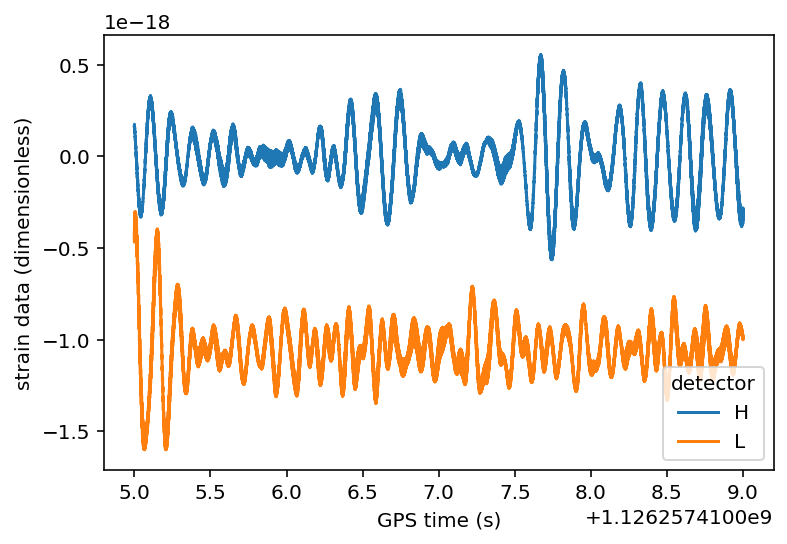

In [25]:
for ifo, d in data_dict.items():
    epoch = d.index[0]
    plt.plot(d[:epoch+4], label=ifo)
plt.legend(title="detector", loc="lower right")
plt.xlabel("GPS time (s)")
plt.ylabel("strain data (dimensionless)");

### Split into segments

Splitting the data into $4s$ is quite trivial:

In [50]:
# duration of segment in seconds
T = 4

segment_dict = {}
for ifo, d in data_dict.items():
    # sampling interval
    dt = d.index[1] - d.index[0]
    # segment length
    N = int(round(T / dt))
    # number of segments
    N_segments = int(len(d) / N)
    segment_dict[ifo] = [d.iloc[k*N:k*N+N] for k in range(N_segments)]

In [51]:
for ifo, segments in segment_dict.items():
    print(f"There are {len(segments)} {ifo} segments.")

There are 1024 H segments.
There are 1024 L segments.


In this case, we know there is a true signal at GPS time $t = 1126259462.4 s$ so make sure to throw away that segment.

In [52]:
t0 = 1126259462.4

for ifo, segments in segment_dict.items():
    segment_dict[ifo] = [s for s in segments if (t0 < s.index[0] or t0 > s.index[-1])]

In [53]:
for ifo, segments in segment_dict.items():
    print(f"There are {len(segments)} {ifo} segments.")

There are 1023 H segments.
There are 1023 L segments.
